In [1]:
from pathlib import Path
import sys
import platform
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, silhouette_score
)
import json
SEED = 42
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

import joblib
import torch
import torch.nn as nn

## 1. Create required folders

In [2]:
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("models").mkdir(parents=True, exist_ok=True)

print("Folders created")


Folders created


## 2. Generate the supplied dataset

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(202)
n = 300
cols = ['distance', 'load', 'traffic', 'staff']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, 0.9, 1.2, -0.8])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["late"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_b.csv", index=False)


## 3. Load and inspect the data

In [4]:
df = pd.read_csv("data/raw/set_b.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget counts:")
print(df["late"].value_counts())


   record_id  distance   load  traffic  staff group  late
0          1     68.12  42.71    39.14  45.98    G2     1
1          2     38.47  65.08    58.80  56.38    G1     1
2          3     64.10  43.99    36.86  53.47    G2     0
3          4     53.09  41.44    55.36  64.72    G1     1
4          5     44.67  51.95    53.44  54.86    G1     1

Shape: (305, 7)

Missing values:
record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

Duplicate rows: 5

Target counts:
late
0    156
1    149
Name: count, dtype: int64


## 4. Remove exact duplicate rows

In [5]:
df_clean = df.drop_duplicates().copy()

print("Rows before:", len(df))
print("Rows after :", len(df_clean))
print("Unique record IDs:", df_clean["record_id"].nunique())


Rows before: 305
Rows after : 300
Unique record IDs: 300


## 5. Separate features and target

In [6]:
X = df_clean.drop(columns=["late"])
y = df_clean["late"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:", y.name)


Features:
['record_id', 'distance', 'load', 'traffic', 'staff', 'group']

Target: late


## 6. Create train, validation and test sets

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Fit:", len(X_fit))
print("Validation:", len(X_val))
print("Test:", len(X_test))


Fit: 192
Validation: 48
Test: 60


## 7. Save split IDs

In [8]:
split_df = pd.DataFrame({
    "record_id": list(X_fit["record_id"]) +
                  list(X_val["record_id"]) +
                  list(X_test["record_id"]),
    "partition": ["fit"] * len(X_fit) +
                 ["validation"] * len(X_val) +
                 ["test"] * len(X_test)
})

split_df.to_csv(
    "outputs/splits.csv",
    index=False
)

print(split_df["partition"].value_counts())


partition
fit           192
test           60
validation     48
Name: count, dtype: int64


## 8. Check that partitions do not overlap

In [9]:
fit_ids = set(X_fit["record_id"])
val_ids = set(X_val["record_id"])
test_ids = set(X_test["record_id"])

print("Fit & Validation:", len(fit_ids & val_ids))
print("Fit & Test:", len(fit_ids & test_ids))
print("Validation & Test:", len(val_ids & test_ids))


Fit & Validation: 0
Fit & Test: 0
Validation & Test: 0


# MODULE 1 — MATHS & ADVANCED STATISTICS

## M1. Distance descriptive statistics

In [10]:
from scipy import stats

distance_fit = X_fit["distance"].dropna()

n_distance = distance_fit.count()
mean_distance = distance_fit.mean()
median_distance = distance_fit.median()
std_distance = distance_fit.std(ddof=1)

print("Observed n:", n_distance)
print("Mean:", mean_distance)
print("Median:", median_distance)
print("Sample standard deviation:", std_distance)


Observed n: 184
Mean: 49.74440217391305
Median: 50.2
Sample standard deviation: 10.835872254207478


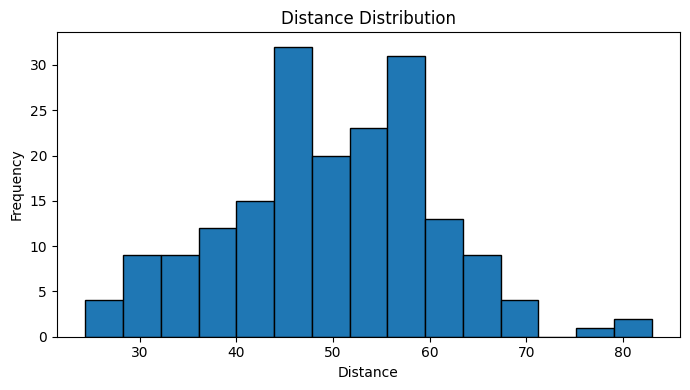

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(distance_fit, bins=15, edgecolor="black")
plt.title("Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/figures/distance_histogram.png", dpi=150)
plt.show()

## M2. Welch two-sided t-test

In [12]:
g1 = X_fit[X_fit["group"] == "G1"]["distance"].dropna()

g2 = X_fit[X_fit["group"] == "G2"]["distance"].dropna()

t_stat, p_value = stats.ttest_ind(g1,g2,equal_var=False)

print("G1 count:", len(g1))
print("G2 count:", len(g2))
print("t-statistic:", t_stat)
print("p-value:", p_value)


G1 count: 104
G2 count: 80
t-statistic: 0.7061612423464614
p-value: 0.48105881393425987


In [13]:
alpha = 0.05

print("H0: Mean distance of G1 = Mean distance of G2")
print("H1: Mean distance of G1 != Mean distance of G2")

if p_value < alpha:
    print("\nDecision: Reject H0")
else:
    print("\nDecision: Fail to reject H0")


H0: Mean distance of G1 = Mean distance of G2
H1: Mean distance of G1 != Mean distance of G2

Decision: Fail to reject H0


## M2. 95% confidence interval for mean distance

In [14]:
standard_error = std_distance / np.sqrt(n_distance)
t_value = stats.t.ppf(0.975,df=n_distance - 1)
margin = t_value * standard_error

ci_lower = mean_distance - margin
ci_upper = mean_distance + margin

print("95% Confidence Interval")
print("Lower:", ci_lower)
print("Upper:", ci_upper)


95% Confidence Interval
Lower: 48.16829889365394
Upper: 51.320505454172164


## M3. Covariance matrix for distance and traffic

In [15]:
matrix_data = X_fit[["distance", "traffic"]].dropna()

X_matrix = matrix_data.values

X_centered = X_matrix - X_matrix.mean(axis=0)

print("Complete rows:", len(X_matrix))
print("\nFirst 5 centered rows:")
print(X_centered[:5])


Complete rows: 184

First 5 centered rows:
[[  6.10559783  -6.78494565]
 [  2.00559783 -12.83494565]
 [  9.24559783  15.84505435]
 [  8.29559783   3.97505435]
 [  7.85559783 -11.74494565]]


In [16]:
n_matrix = len(X_centered)

cov_matrix = (X_centered.T @ X_centered) / (n_matrix - 1)

print("Sample covariance matrix:")
print(cov_matrix)


Sample covariance matrix:
[[117.41612751  -1.23645741]
 [ -1.23645741 107.43358798]]


## M3. Eigenvalues and principal direction

In [17]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
largest_index = np.argmax(eigenvalues)
largest_eigenvalue = eigenvalues[largest_index]
variance_share = (largest_eigenvalue /eigenvalues.sum())
principal_direction = eigenvectors[:, largest_index]

print("Eigenvalues:")
print(eigenvalues)
print("\nLargest eigenvalue:",largest_eigenvalue)
print("\nVariance share:",variance_share)
print("Variance share %:",variance_share * 100)
print("\nPrincipal direction:")
print(principal_direction)

Eigenvalues:
[107.28271803 117.56699745]

Largest eigenvalue: 117.5669974540402

Variance share: 0.5228692293455571
Variance share %: 52.28692293455571

Principal direction:
[-0.99263792  0.1211196 ]


## Task 2 — Data Preprocessing & Feature Engineering (5 Marks)
### F1 — Audit and Partition (2 Marks)
### F2 — Transform and Engineer (2 Marks)
### F3 — Leakage Evidence (1 Mark)


## Define numeric and categorical columns

In [18]:
numeric_cols = ["distance","load","traffic","staff"]

categorical_cols = ["group"]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['distance', 'load', 'traffic', 'staff']
Categorical columns: ['group']


## Median imputation — fit only on fit data

In [19]:
imputer = SimpleImputer(strategy="median")

X_fit_num = imputer.fit_transform(X_fit[numeric_cols])

X_val_num = imputer.transform(X_val[numeric_cols])

X_test_num = imputer.transform(X_test[numeric_cols])


print("Fit shape:", X_fit_num.shape)
print("Validation shape:", X_val_num.shape)
print("Test shape:", X_test_num.shape)


Fit shape: (192, 4)
Validation shape: (48, 4)
Test shape: (60, 4)


## Convert imputed numeric data back to DataFrames

In [20]:
fit_num_df = pd.DataFrame(X_fit_num,columns=numeric_cols,index=X_fit.index)
val_num_df = pd.DataFrame(X_val_num,columns=numeric_cols,index=X_val.index)
test_num_df = pd.DataFrame(X_test_num,columns=numeric_cols,index=X_test.index)

## Create the required engineered feature

In [21]:
fit_num_df["engineered_feature"] = (fit_num_df["load"] /(fit_num_df["staff"] + 1))
val_num_df["engineered_feature"] = (val_num_df["load"] /(val_num_df["staff"] + 1))
test_num_df["engineered_feature"] = (test_num_df["load"] /(test_num_df["staff"] + 1))

print(fit_num_df.head())


     distance    load  traffic  staff  engineered_feature
288     55.85  54.680    42.44  54.95            0.977301
73      51.75  47.550    36.39  36.13            1.280636
259     58.99  38.830    65.07  53.74            0.709353
280     58.04  37.760    53.20  53.97            0.686920
243     57.60  49.965    37.48  57.45            0.854833


## One-hot encode group

In [22]:
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

fit_group = encoder.fit_transform(X_fit[categorical_cols])
val_group = encoder.transform(X_val[categorical_cols])
test_group = encoder.transform(X_test[categorical_cols])
group_names = encoder.get_feature_names_out(categorical_cols)

print("Encoded columns:", group_names)


Encoded columns: ['group_G1' 'group_G2']


## Standardize numeric features

In [23]:
feature_numeric_cols = ["distance","load","traffic","staff","engineered_feature"]

scaler = StandardScaler()

fit_scaled = scaler.fit_transform(fit_num_df[feature_numeric_cols])
val_scaled = scaler.transform(val_num_df[feature_numeric_cols])
test_scaled = scaler.transform(test_num_df[feature_numeric_cols])

print("Scaling completed")


Scaling completed


## Combine numeric and one-hot features

In [24]:
feature_names = (feature_numeric_cols +list(group_names))

X_fit_final = np.hstack([fit_scaled,fit_group])
X_val_final = np.hstack([val_scaled,val_group])
X_test_final = np.hstack([test_scaled,test_group])

print("Fit shape:", X_fit_final.shape)
print("Validation shape:", X_val_final.shape)
print("Test shape:", X_test_final.shape)

print("\nFinal features:")
print(feature_names)


Fit shape: (192, 7)
Validation shape: (48, 7)
Test shape: (60, 7)

Final features:
['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']


## Check transformed data

In [25]:
print("Fit values finite:",np.isfinite(X_fit_final).all())
print("Validation values finite:",np.isfinite(X_val_final).all())
print("Test values finite:",np.isfinite(X_test_final).all())
print("Number of final features:",X_fit_final.shape[1])


Fit values finite: True
Validation values finite: True
Test values finite: True
Number of final features: 7


In [26]:
preprocess_info = pd.DataFrame({"feature_name": feature_names})
preprocess_info.to_csv("outputs/preprocessing_features.csv",index=False)
print("Preprocessing information saved")


Preprocessing information saved


## Task 3 — Supervised Learning (5 Marks)
### S1 — Baseline and Classifier (2 Marks)
### S2 — Holdout Evaluation (2 Marks)
### S3 — Interpretation (1 Mark)


## Majority-class baseline

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_fit_final,y_fit)
dummy_pred = dummy_model.predict(X_test_final)
dummy_accuracy = accuracy_score(y_test,dummy_pred)

print("Dummy accuracy:", dummy_accuracy)


Dummy accuracy: 0.5166666666666667


## Logistic Regression

In [28]:
log_model = LogisticRegression(max_iter=1000,random_state=42)
log_model.fit(X_fit_final,y_fit)
log_pred = log_model.predict(X_test_final)
log_prob = log_model.predict_proba(X_test_final)[:, 1]

print("Logistic Regression trained")


Logistic Regression trained


## Logistic Regression metrics

In [29]:
log_accuracy = accuracy_score(y_test,log_pred)
log_precision = precision_score(y_test,log_pred,zero_division=0)
log_recall = recall_score(y_test,log_pred,zero_division=0)
log_f1 = f1_score(y_test,log_pred,zero_division=0)

print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)


Accuracy : 0.85
Precision: 0.8846153846153846
Recall   : 0.7931034482758621
F1 Score : 0.8363636363636363


## Logistic Regression confusion matrix

[[28  3]
 [ 6 23]]


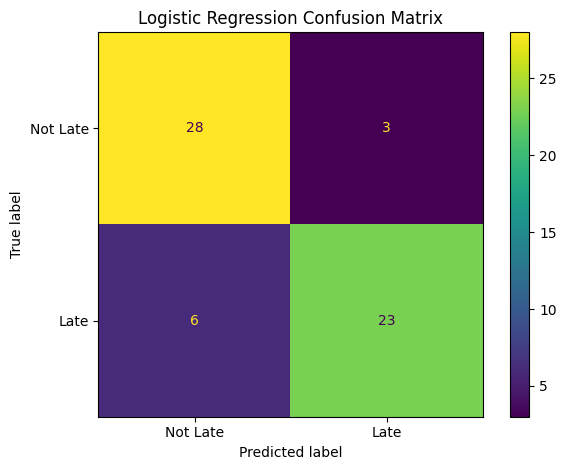

In [30]:
cm = confusion_matrix(y_test,log_pred)
print(cm)

display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Not Late","Late"])
display.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/figures/logistic_confusion_matrix.png",dpi=150)
plt.show()

## Save Logistic Regression test predictions

In [31]:
log_predictions = pd.DataFrame({
    "record_id": X_test["record_id"].values,
    "true_label": y_test.values,
    "predicted_label": log_pred,
    "class_1_probability": log_prob
})

log_predictions.to_csv("outputs/logistic_predictions.csv",index=False)
print(log_predictions.head())


   record_id  true_label  predicted_label  class_1_probability
0         50           0                0             0.034625
1        231           0                0             0.074453
2        297           0                0             0.006790
3         97           0                0             0.112015
4        285           0                0             0.040311


## Task 4 — Unsupervised Learning (5 Marks)
### U1 — K-Means and Selection (3 Marks)
### |U2 — Segment Interpretation (2 Mark)


## Test k = 2, 3, 4

In [32]:
cluster_data = fit_scaled

k_results = []

for k in [2, 3, 4]:

    model = KMeans(n_clusters=k,n_init=10,random_state=42)
    labels = model.fit_predict(cluster_data)
    inertia = model.inertia_
    silhouette = silhouette_score(cluster_data,labels)
    k_results.append([k,inertia,silhouette])

k_results = pd.DataFrame(
    k_results,columns=["k","inertia","silhouette"]
)

print(k_results)


   k     inertia  silhouette
0  2  719.632089    0.246337
1  3  599.659398    0.207147
2  4  535.383548    0.190232


## Select k using silhouette score

In [33]:
best_k = k_results.sort_values(by=["silhouette", "k"],ascending=[False, True]).iloc[0]["k"]
best_k = int(best_k)

print("Selected k:", best_k)


Selected k: 2


## Final K-Means

In [34]:
final_kmeans = KMeans(n_clusters=best_k,n_init=10,random_state=42)

cluster_labels = final_kmeans.fit_predict(cluster_data)

fit_num_df["cluster"] = cluster_labels

print(fit_num_df["cluster"].value_counts().sort_index())


cluster
0    134
1     58
Name: count, dtype: int64


## Cluster profiles

In [35]:
cluster_profile = fit_num_df.groupby("cluster")[feature_numeric_cols].mean()
print(cluster_profile)

          distance       load    traffic      staff  engineered_feature
cluster                                                                
0        48.418955  47.127985  49.066269  54.035000            0.863256
1        52.869483  57.461552  49.856207  41.426724            1.372952


## Save K-Means results

In [36]:
k_results.to_csv("outputs/kmeans_scores.csv",index=False)
cluster_profile.to_csv("outputs/cluster_profiles.csv")
cluster_output = pd.DataFrame({"record_id": X_fit["record_id"].values,"cluster": cluster_labels})
cluster_output.to_csv("outputs/cluster_assignments.csv",index=False)

print("K-Means results saved")


K-Means results saved


## Task 5 — Deep Learning up to ANN (5 Marks)
### D1 — ANN Architecture and Compilation (2 Marks)
### D2 — Training and Validation (2 Marks)
### D3 — Comparison and Evidence (1 Mark)


## Import TensorFlow / Keras

## Build ANN: 16 ReLU → 8 ReLU → 1 Sigmoid

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

input_size = X_fit_final.shape[1]


ann = Sequential([Dense(16,activation="relu",input_shape=(input_size,)),
                  Dense(8,activation="relu"),
                  Dense(1,activation="sigmoid")])

ann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"])

ann.summary()


C:\Users\dharm\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

## Count trainable parameters

In [38]:
trainable_params = 0

for variable in ann.trainable_variables:
    trainable_params += np.prod(variable.shape)

print("Trainable parameters:", trainable_params)


Trainable parameters: 273


## Early stopping

In [39]:
early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

## Train ANN

In [40]:
history = ann.fit(X_fit_final,y_fit,
    validation_data=(X_val_final,y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1)

print("Actual epochs:",len(history.history["loss"]))


Epoch 1/50


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5156 - loss: 0.7597 - val_accuracy: 0.4792 - val_loss: 0.7247
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5417 - loss: 0.7331 - val_accuracy: 0.5208 - val_loss: 0.7070
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5521 - loss: 0.7116 - val_accuracy: 0.5208 - val_loss: 0.6924
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5625 - loss: 0.6938 - val_accuracy: 0.5417 - val_loss: 0.6797
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6042 - loss: 0.6787 - val_accuracy: 0.5625 - val_loss: 0.6692
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 0.6655 - val_accuracy: 0.6042 - val_loss: 0.6600
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6354 - loss: 0.6538 - val_accuracy: 0.6042 - val_loss: 0.6510
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6562 - loss: 0.6426 - val_accuracy: 0.6250 - val_loss: 0.64

## ANN loss curve

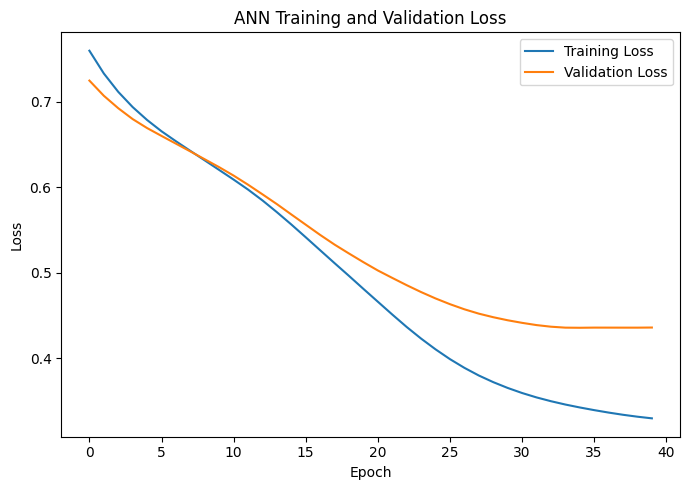

In [41]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/ann_loss_curve.png",dpi=150)

plt.show()

## ANN test prediction

In [42]:
ann_prob = ann.predict(X_test_final,verbose=0).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

print(ann_pred[:10])

[0 0 0 0 0 1 1 0 1 0]


## ANN metrics

In [43]:
ann_accuracy = accuracy_score(y_test,ann_pred)
ann_precision = precision_score(y_test,ann_pred,zero_division=0)
ann_recall = recall_score(y_test,ann_pred,zero_division=0)
ann_f1 = f1_score(y_test,ann_pred,zero_division=0)

print("Accuracy :", ann_accuracy)
print("Precision:", ann_precision)
print("Recall   :", ann_recall)
print("F1 Score :", ann_f1)


Accuracy : 0.8333333333333334
Precision: 0.8518518518518519
Recall   : 0.7931034482758621
F1 Score : 0.8214285714285714


## ANN confusion matrix

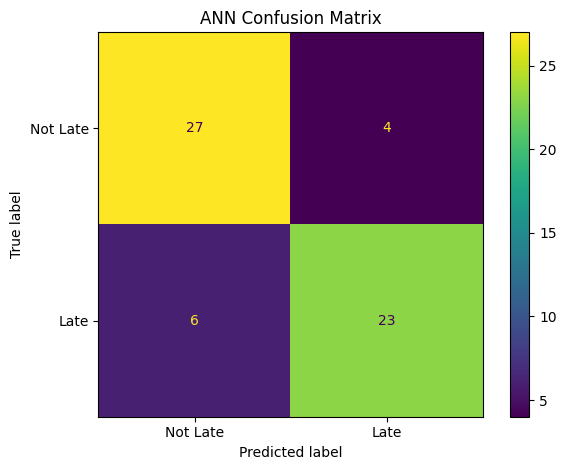

In [44]:
ann_cm = confusion_matrix(y_test,ann_pred)

display = ConfusionMatrixDisplay(confusion_matrix=ann_cm,
    display_labels=[
        "Not Late",
        "Late"
    ])

display.plot()
plt.title("ANN Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/figures/ann_confusion_matrix.png",dpi=150)
plt.show()


## Save ANN predictions

In [45]:
ann_predictions = pd.DataFrame({
    "record_id": X_test["record_id"].values,
    "true_label": y_test.values,
    "predicted_label": ann_pred,
    "class_1_probability": ann_prob
})

ann_predictions.to_csv("outputs/ann_predictions.csv",index=False)
print(ann_predictions.head())


   record_id  true_label  predicted_label  class_1_probability
0         50           0                0             0.070560
1        231           0                0             0.049791
2        297           0                0             0.004598
3         97           0                0             0.214132
4        285           0                0             0.082791


## Compare all models

In [46]:
comparison = pd.DataFrame({
    "model": ["Dummy Classifier","Logistic Regression","ANN"],

    "accuracy": [dummy_accuracy,log_accuracy,ann_accuracy],

    "precision": [np.nan,log_precision,ann_precision],

    "recall": [np.nan,log_recall,ann_recall],

    "f1": [np.nan,log_f1,ann_f1]
})

print(comparison)


                 model  accuracy  precision    recall        f1
0     Dummy Classifier  0.516667        NaN       NaN       NaN
1  Logistic Regression  0.850000   0.884615  0.793103  0.836364
2                  ANN  0.833333   0.851852  0.793103  0.821429


## Simple result observation

In [47]:
print("Logistic Regression F1:", log_f1)
print("ANN F1:", ann_f1)

if ann_f1 > log_f1:
    print("\nANN has the higher F1 score on this test set.")
else:
    print("\nLogistic Regression has the higher F1 score on this test set.")


Logistic Regression F1: 0.8363636363636363
ANN F1: 0.8214285714285714

Logistic Regression has the higher F1 score on this test set.


## Save model comparison and ANN

In [48]:
comparison.to_csv("outputs/model_comparison.csv",index=False)
ann.save("models/ann_model.keras")
print("Model files saved")


Model files saved


## Final statistics summary

In [49]:
statistics_summary = pd.DataFrame({
    "metric": [
        "distance_n",
        "distance_mean",
        "distance_median",
        "distance_std",
        "welch_t_stat",
        "welch_p_value",
        "ci_lower",
        "ci_upper",
        "largest_eigenvalue",
        "variance_share"
    ],

    "value": [
        n_distance,
        mean_distance,
        median_distance,
        std_distance,
        t_stat,
        p_value,
        ci_lower,
        ci_upper,
        largest_eigenvalue,
        variance_share
    ]
})

statistics_summary.to_csv("outputs/statistics_summary.csv",index=False)
print(statistics_summary)


               metric       value
0          distance_n  184.000000
1       distance_mean   49.744402
2     distance_median   50.200000
3        distance_std   10.835872
4        welch_t_stat    0.706161
5       welch_p_value    0.481059
6            ci_lower   48.168299
7            ci_upper   51.320505
8  largest_eigenvalue  117.566997
9      variance_share    0.522869


## Final practical check

In [50]:
print("========== FINAL CHECK ==========")

print("\nDataset")
print("Original rows:", len(df))
print("Clean rows:", len(df_clean))

print("\nSplit")
print("Fit:", len(X_fit))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nLogistic Regression")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1:", log_f1)

print("\nANN")
print("Accuracy:", ann_accuracy)
print("Precision:", ann_precision)
print("Recall:", ann_recall)
print("F1:", ann_f1)

print("\nK-Means")
print("Selected k:", best_k)

print("\nANN epochs:",
      len(history.history["loss"]))

print("\nNotebook completed successfully")


========== FINAL CHECK ==========

Dataset
Original rows: 305
Clean rows: 300

Split
Fit: 192
Validation: 48
Test: 60

Logistic Regression
Accuracy: 0.85
Precision: 0.8846153846153846
Recall: 0.7931034482758621
F1: 0.8363636363636363

ANN
Accuracy: 0.8333333333333334
Precision: 0.8518518518518519
Recall: 0.7931034482758621
F1: 0.8214285714285714

K-Means
Selected k: 2

ANN epochs: 40

Notebook completed successfully


In [51]:
# ==========================================
# FINAL FILE CHECKLIST
# ==========================================

import os

required_files = [
    # Dataset
    "data/raw/set_b.csv",

    # Outputs
    "outputs/splits.csv",
    "outputs/preprocessing_features.csv",
    "outputs/logistic_predictions.csv",
    "outputs/kmeans_scores.csv",
    "outputs/cluster_profiles.csv",
    "outputs/cluster_assignments.csv",
    "outputs/ann_predictions.csv",
    "outputs/model_comparison.csv",
    "outputs/statistics_summary.csv",

    # Figures
    "outputs/figures/distance_histogram.png",
    "outputs/figures/logistic_confusion_matrix.png",
    "outputs/figures/ann_loss_curve.png",
    "outputs/figures/ann_confusion_matrix.png",

    # Model
    "models/ann_model.keras"
]

print("=" * 60)
print("FINAL FILE CHECKLIST")
print("=" * 60)

missing_files = []

for file in required_files:
    if os.path.exists(file):
        print(f"✓ {file}")
    else:
        print(f"✗ MISSING: {file}")
        missing_files.append(file)

print("=" * 60)

if len(missing_files) == 0:
    print("✓ ALL REQUIRED FILES ARE PRESENT")
    print("✓ PROJECT IS READY FOR SUBMISSION")
else:
    print(f"✗ {len(missing_files)} FILE(S) ARE MISSING")
    print("\nMissing files:")
    for file in missing_files:
        print(f"  - {file}")

print("=" * 60)

FINAL FILE CHECKLIST
✓ data/raw/set_b.csv
✓ outputs/splits.csv
✓ outputs/preprocessing_features.csv
✓ outputs/logistic_predictions.csv
✓ outputs/kmeans_scores.csv
✓ outputs/cluster_profiles.csv
✓ outputs/cluster_assignments.csv
✓ outputs/ann_predictions.csv
✓ outputs/model_comparison.csv
✓ outputs/statistics_summary.csv
✓ outputs/figures/distance_histogram.png
✓ outputs/figures/logistic_confusion_matrix.png
✓ outputs/figures/ann_loss_curve.png
✓ outputs/figures/ann_confusion_matrix.png
✓ models/ann_model.keras
✓ ALL REQUIRED FILES ARE PRESENT
✓ PROJECT IS READY FOR SUBMISSION
